Using device: cuda


100%|██████████| 170M/170M [01:42<00:00, 1.66MB/s]


Training images: 4000
Validation images: 1000
Testing images: 1000

MODEL: AlexNet

Loading pretrained AlexNet...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 175MB/s]



Epoch 1/3
Train Loss: 0.9454 | Train Accuracy: 66.77%
Val Loss: 0.7780 | Val Accuracy: 74.40%

Epoch 2/3
Train Loss: 0.6774 | Train Accuracy: 76.92%
Val Loss: 0.6886 | Val Accuracy: 76.60%

Epoch 3/3
Train Loss: 0.5571 | Train Accuracy: 80.15%
Val Loss: 0.6859 | Val Accuracy: 78.30%

Test Accuracy: 76.20%
Test Loss: 0.7298
Training Time: 29.85 seconds

MODEL: VGG16

Loading pretrained VGG16...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


...


Epoch 1/3
Train Loss: 0.8553 | Train Accuracy: 70.28%
Val Loss: 0.6057 | Val Accuracy: 78.80%

Epoch 2/3
Train Loss: 0.6157 | Train Accuracy: 78.00%
Val Loss: 0.5659 | Val Accuracy: 81.80%

Epoch 3/3
Train Loss: 0.5511 | Train Accuracy: 80.47%
Val Loss: 0.5760 | Val Accuracy: 81.90%

Test Accuracy: 78.70%
Test Loss: 0.5900
Training Time: 89.80 seconds

MODEL: ResNet50

Loading pretrained ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]



Epoch 1/3
Train Loss: 1.3753 | Train Accuracy: 58.85%
Val Loss: 0.9361 | Val Accuracy: 71.40%

Epoch 2/3
Train Loss: 0.8977 | Train Accuracy: 72.05%
Val Loss: 0.7807 | Val Accuracy: 75.60%

Epoch 3/3
Train Loss: 0.7679 | Train Accuracy: 75.38%
Val Loss: 0.7107 | Val Accuracy: 77.40%

Test Accuracy: 75.60%
Test Loss: 0.7445
Training Time: 70.72 seconds

MODEL: EfficientNetB0

Loading pretrained EfficientNetB0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]



Epoch 1/3
Train Loss: 1.4657 | Train Accuracy: 56.33%
Val Loss: 0.9876 | Val Accuracy: 73.50%

Epoch 2/3
Train Loss: 0.9843 | Train Accuracy: 69.33%
Val Loss: 0.8094 | Val Accuracy: 75.30%

Epoch 3/3
Train Loss: 0.8712 | Train Accuracy: 72.55%
Val Loss: 0.7612 | Val Accuracy: 76.80%

Test Accuracy: 76.80%
Test Loss: 0.7526
Training Time: 45.11 seconds

FINAL MODEL COMPARISON
         Model  Accuracy (%)  Test Loss  Training Time (sec)
       AlexNet          76.2     0.7298              29.8540
         VGG16          78.7     0.5900              89.8005
      ResNet50          75.6     0.7445              70.7202
EfficientNetB0          76.8     0.7526              45.1065

Best Model: VGG16
Best Accuracy: 78.70%


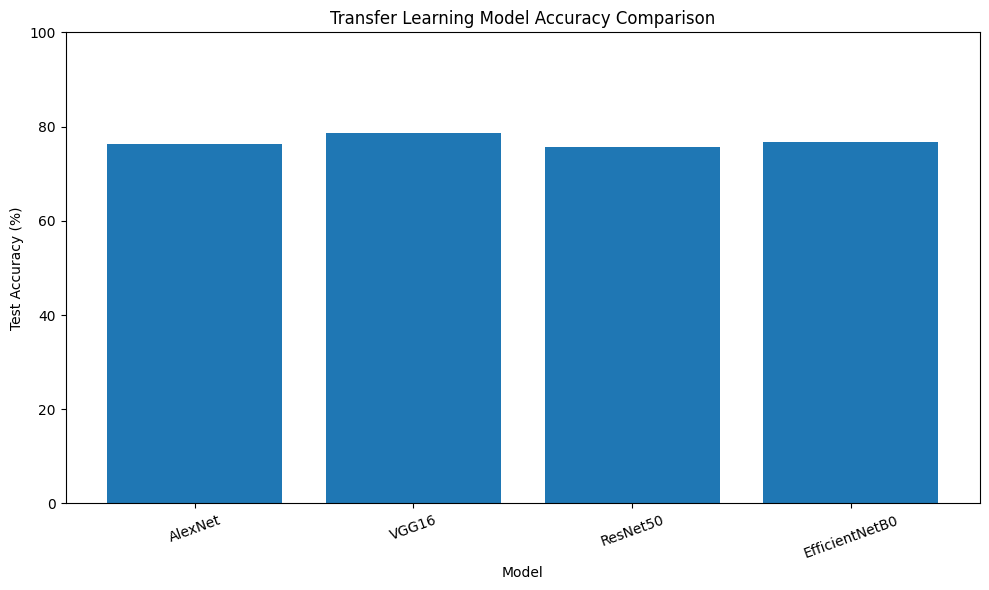

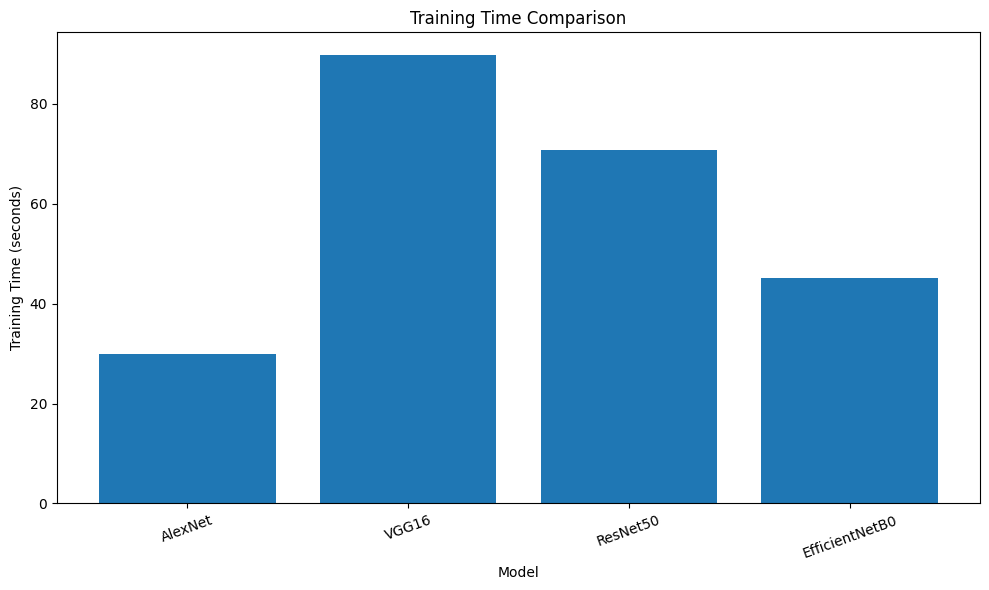

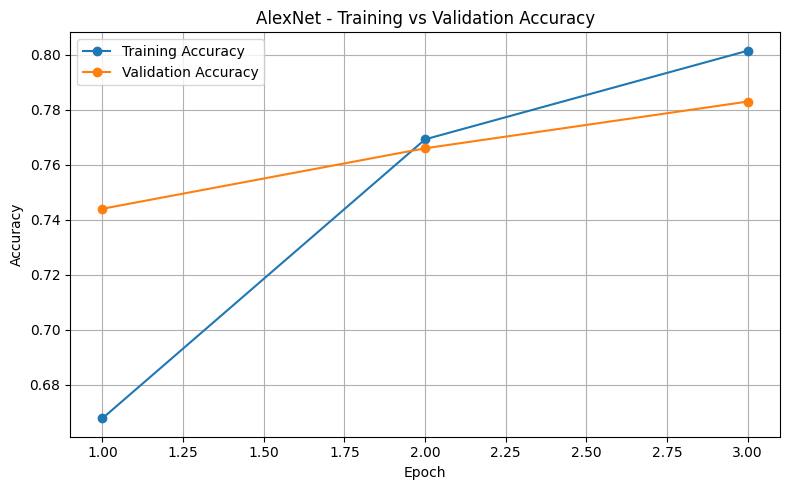

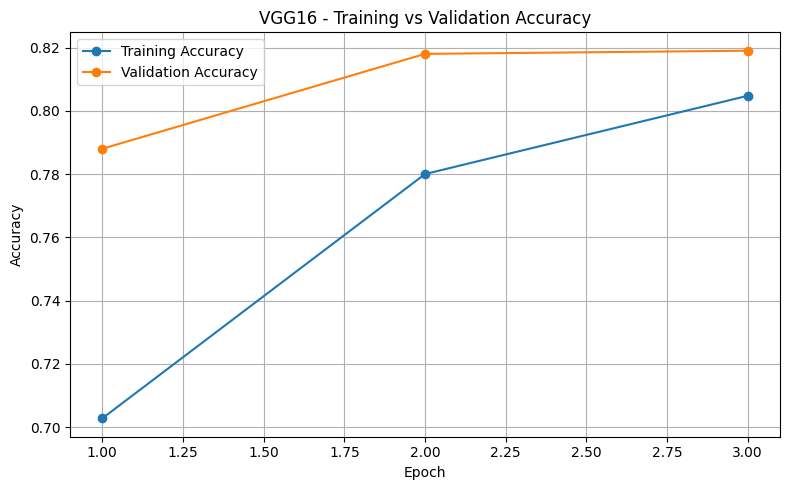

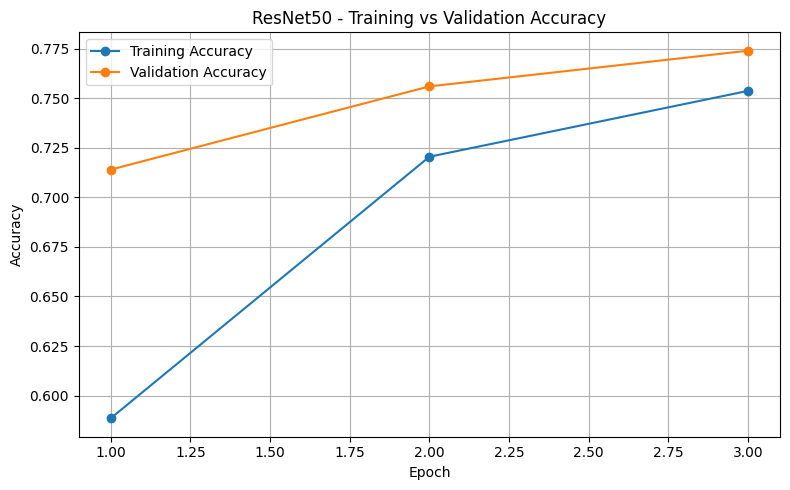

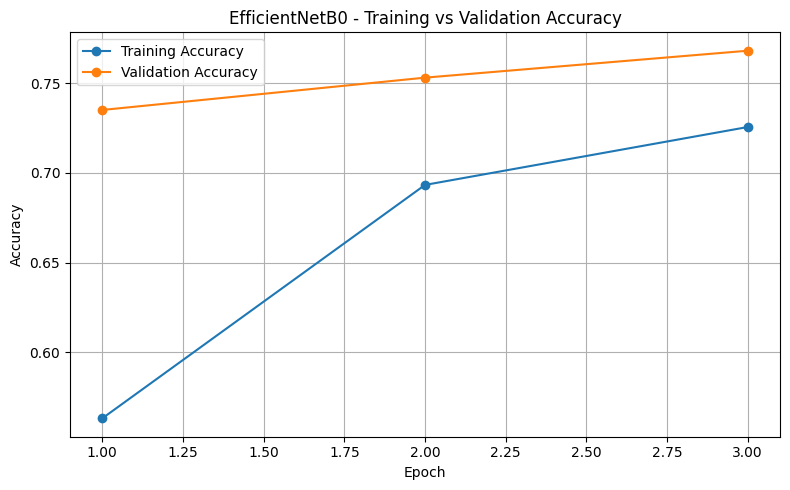

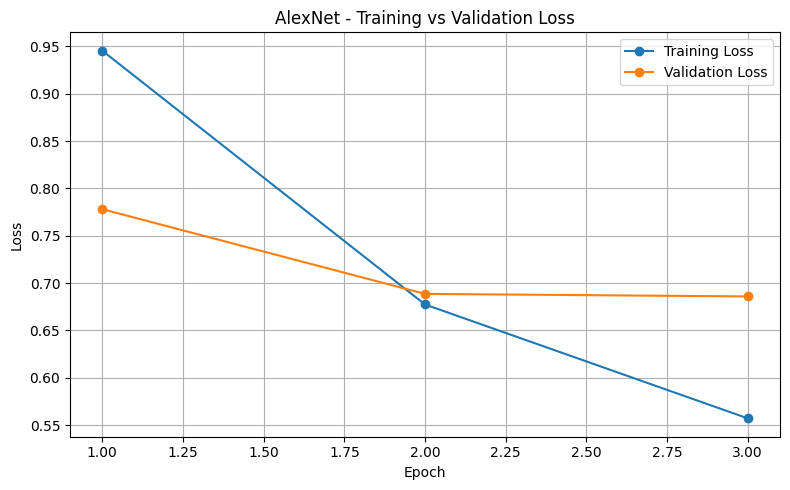

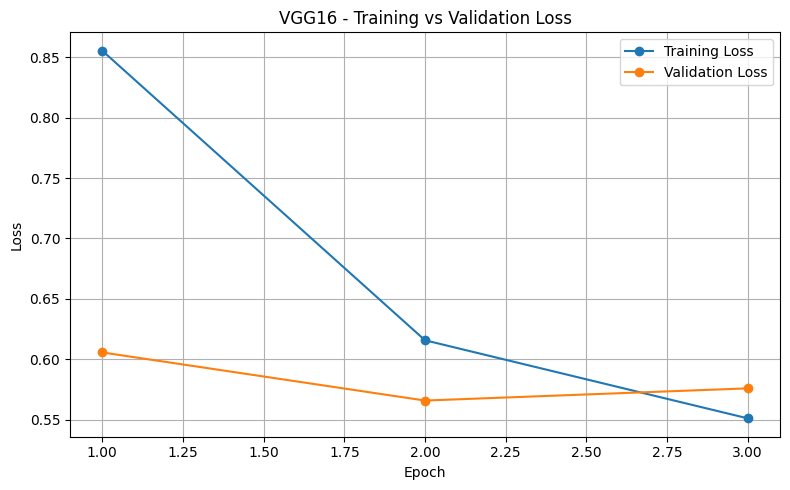

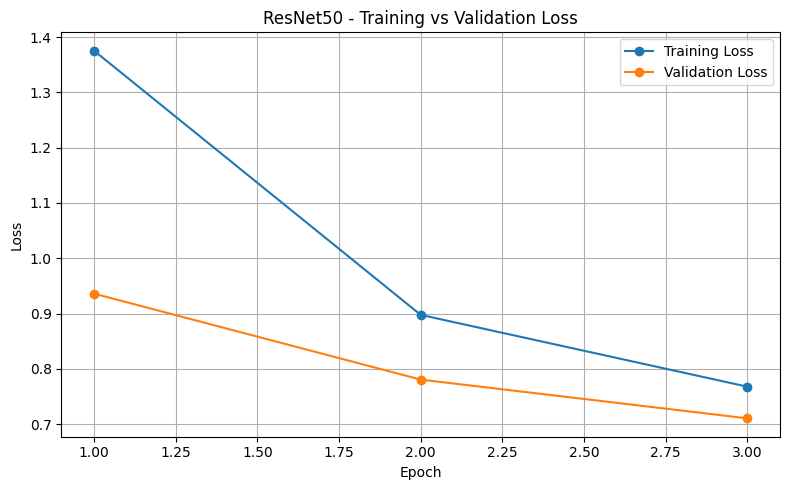

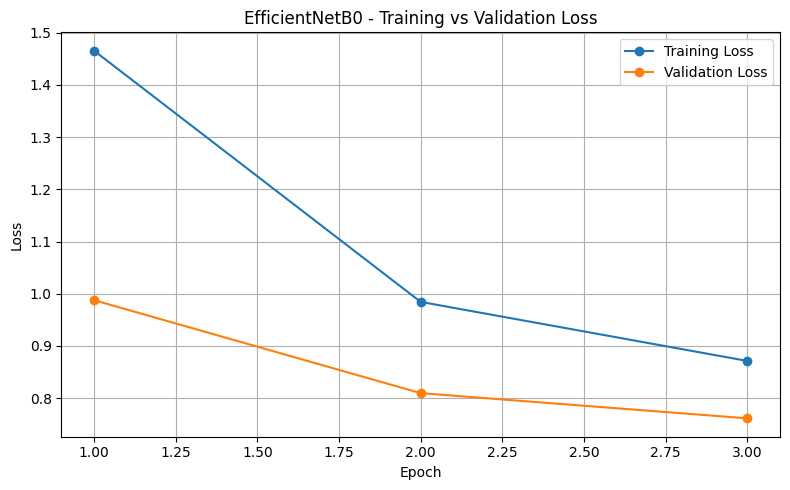

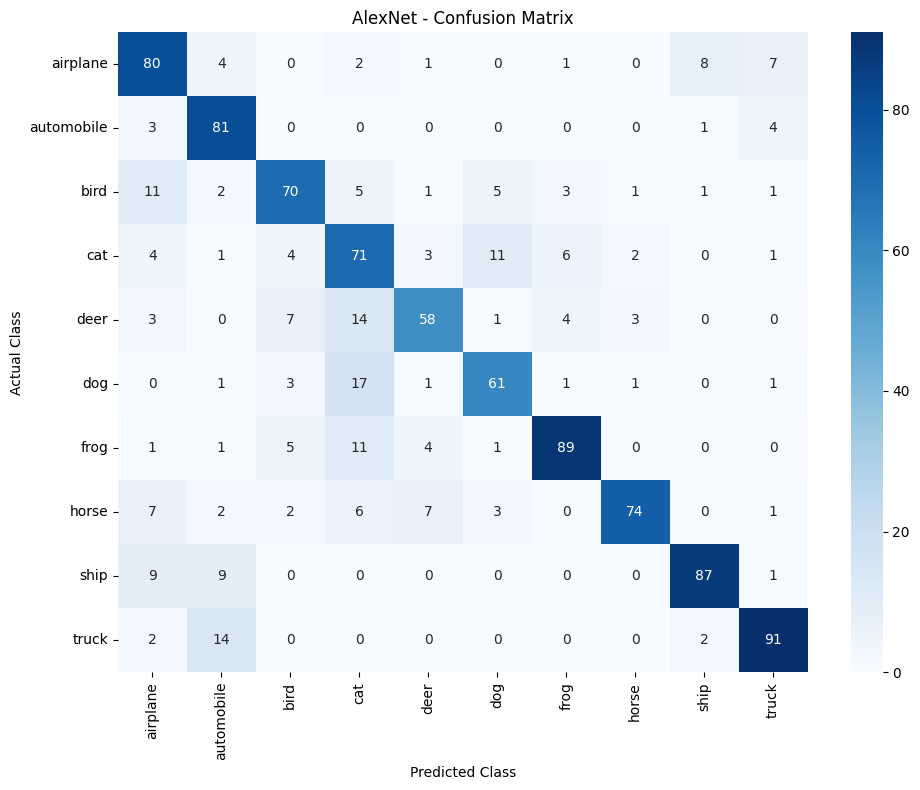

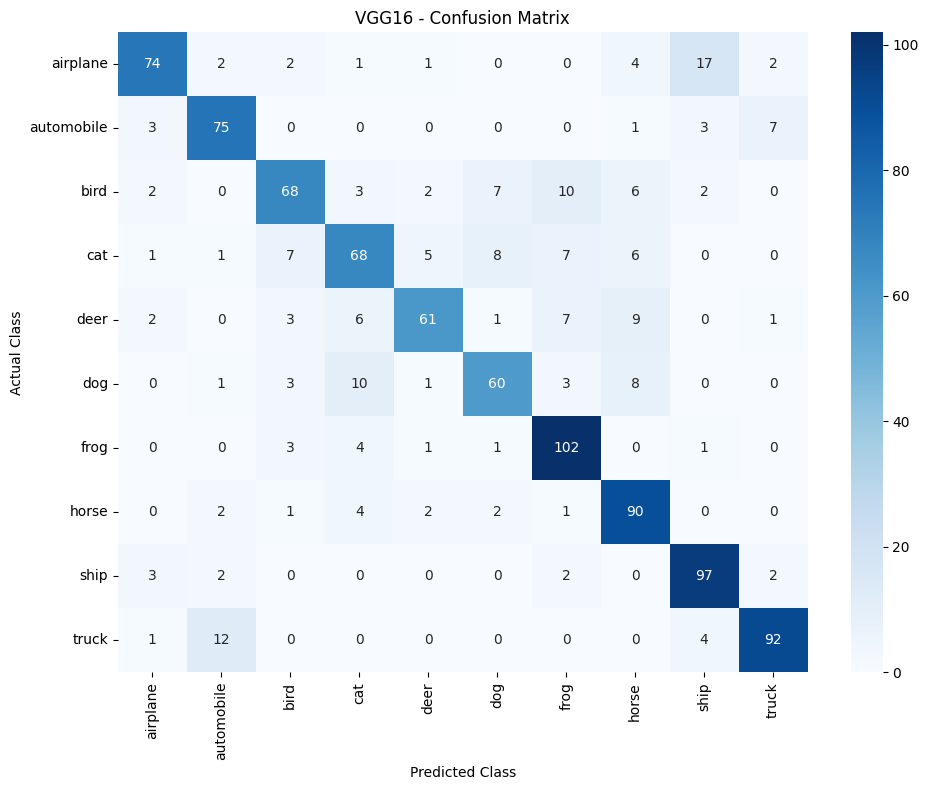

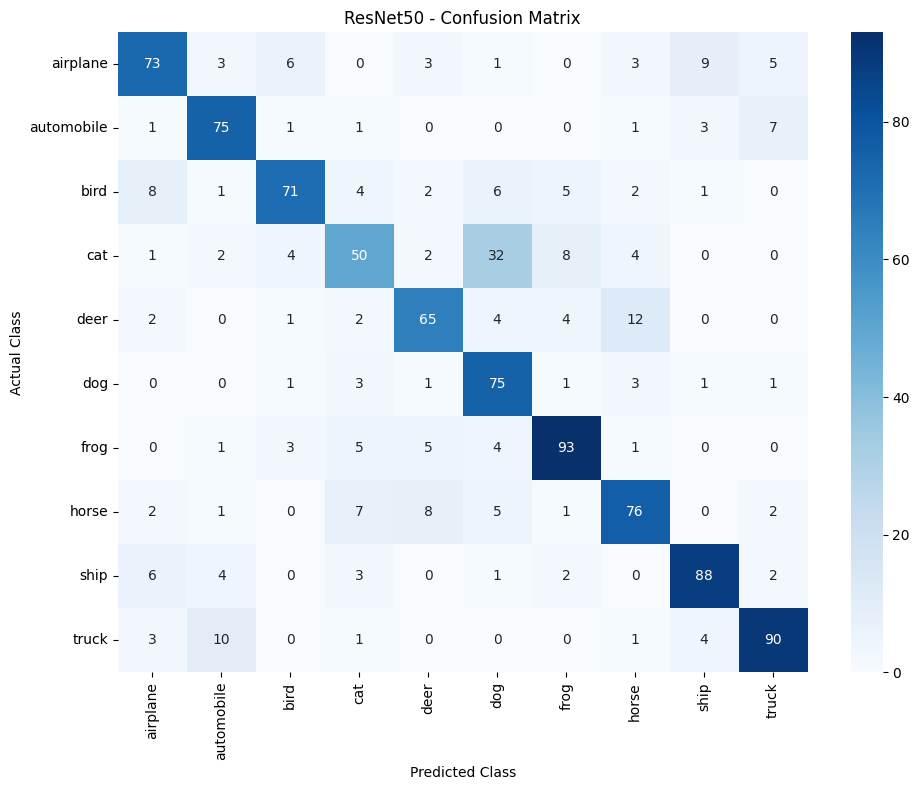

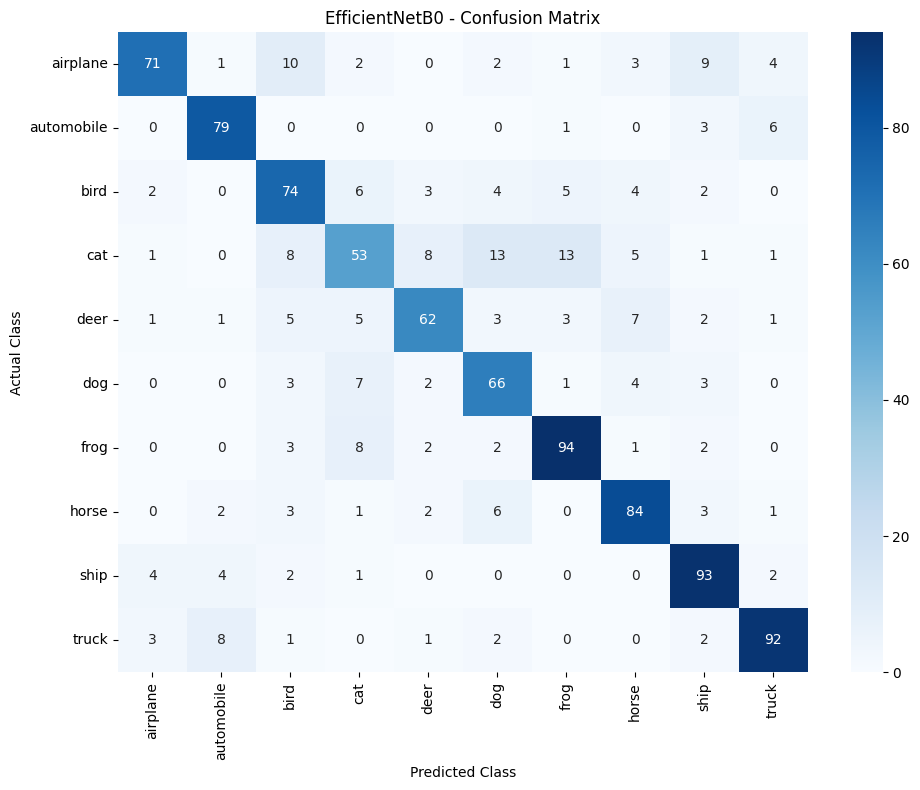


CLASSIFICATION REPORT: AlexNet
              precision    recall  f1-score   support

    airplane       0.67      0.78      0.72       103
  automobile       0.70      0.91      0.79        89
        bird       0.77      0.70      0.73       100
         cat       0.56      0.69      0.62       103
        deer       0.77      0.64      0.70        90
         dog       0.74      0.71      0.73        86
        frog       0.86      0.79      0.82       112
       horse       0.91      0.73      0.81       102
        ship       0.88      0.82      0.85       106
       truck       0.85      0.83      0.84       109

    accuracy                           0.76      1000
   macro avg       0.77      0.76      0.76      1000
weighted avg       0.77      0.76      0.76      1000


CLASSIFICATION REPORT: VGG16
              precision    recall  f1-score   support

    airplane       0.86      0.72      0.78       103
  automobile       0.79      0.84      0.82        89
        bird    

In [ ]:
# ================================================================
# TRANSFER LEARNING USING PRETRAINED:
# AlexNet, VGG16, ResNet50, EfficientNetB0
# Dataset: CIFAR-10
# ================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 3
NUM_CLASSES = 10
TRAIN_SAMPLES = 5000
TEST_SAMPLES = 1000
RANDOM_STATE = 42
LEARNING_RATE = 0.001

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


# ImageNet pretrained models expect normalized RGB images.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# -------------------- LOAD CIFAR-10 --------------------
full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

# Separate copy without augmentation for validation
full_train_dataset_no_aug = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=test_transform
)

full_test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)


# -------------------- TRAIN / VALIDATION SPLIT --------------------
train_indices = np.arange(TRAIN_SAMPLES)
test_indices = np.arange(TEST_SAMPLES)

all_labels = np.array(full_train_dataset.targets)[train_indices]

train_idx, val_idx = train_test_split(
    train_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=all_labels
)

train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_train_dataset_no_aug, val_idx)
test_dataset = Subset(full_test_dataset, test_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))


# -------------------- LOAD PRETRAINED MODELS --------------------
def get_pretrained_model(model_name):

    if model_name == "AlexNet":
        print("\nLoading pretrained AlexNet...")
        model = models.alexnet(
            weights=models.AlexNet_Weights.DEFAULT
        )

        # Freeze all pretrained parameters
        for param in model.parameters():
            param.requires_grad = False

        # Replace ImageNet 1000-class output with CIFAR-10 10-class output
        input_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(
            input_features, NUM_CLASSES
        )

    elif model_name == "VGG16":
        print("\nLoading pretrained VGG16...")
        model = models.vgg16(
            weights=models.VGG16_Weights.DEFAULT
        )

        # Freeze all pretrained parameters
        for param in model.parameters():
            param.requires_grad = False

        input_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(
            input_features, NUM_CLASSES
        )

    elif model_name == "ResNet50":
        print("\nLoading pretrained ResNet50...")
        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        # Freeze all pretrained parameters
        for param in model.parameters():
            param.requires_grad = False

        input_features = model.fc.in_features
        model.fc = nn.Linear(
            input_features, NUM_CLASSES
        )

    elif model_name == "EfficientNetB0":
        print("\nLoading pretrained EfficientNetB0...")
        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        # Freeze all pretrained parameters
        for param in model.parameters():
            param.requires_grad = False

        input_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(
            input_features, NUM_CLASSES
        )

    else:
        raise ValueError("Unknown model name")

    return model.to(device)


# -------------------- TRAINING FUNCTION --------------------
def train_model(model, train_loader, val_loader, epochs):

    criterion = nn.CrossEntropyLoss()

    # Only the newly added classifier layer is trainable
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_val_accuracy = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    start_time = time.time()

    for epoch in range(epochs):

        print(f"\nEpoch {epoch + 1}/{epochs}")

        # ---------------- TRAIN ----------------
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = correct / total

        # ---------------- VALIDATION ----------------
        model.eval()

        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_total += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss_total / val_total
        val_accuracy = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_weights = copy.deepcopy(model.state_dict())

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy * 100:.2f}%"
        )
        print(
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy * 100:.2f}%"
        )

    training_time = time.time() - start_time

    # Restore best validation model
    model.load_state_dict(best_weights)

    return model, history, training_time


# -------------------- TEST FUNCTION --------------------
def evaluate_model(model, test_loader):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = correct / total
    test_loss = total_loss / total

    return (
        accuracy,
        test_loss,
        np.array(all_labels),
        np.array(all_predictions)
    )


# -------------------- RUN ALL FOUR MODELS --------------------
model_names = [
    "AlexNet",
    "VGG16",
    "ResNet50",
    "EfficientNetB0"
]

results = []
histories = {}
true_labels = {}
predictions = {}

for model_name in model_names:

    print("\n" + "=" * 70)
    print("MODEL:", model_name)
    print("=" * 70)

    model = get_pretrained_model(model_name)

    model, history, training_time = train_model(
        model,
        train_loader,
        val_loader,
        EPOCHS
    )

    accuracy, test_loss, y_true, y_pred = evaluate_model(
        model,
        test_loader
    )

    histories[model_name] = history
    true_labels[model_name] = y_true
    predictions[model_name] = y_pred

    results.append({
        "Model": model_name,
        "Test Accuracy": accuracy,
        "Test Loss": test_loss,
        "Training Time (sec)": training_time
    })

    print("\nTest Accuracy:", f"{accuracy * 100:.2f}%")
    print("Test Loss:", f"{test_loss:.4f}")
    print("Training Time:", f"{training_time:.2f} seconds")

    # Free memory before loading next model
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# -------------------- RESULTS TABLE --------------------
results_df = pd.DataFrame(results)

results_df["Accuracy (%)"] = (
    results_df["Test Accuracy"] * 100
)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(
    results_df[
        [
            "Model",
            "Accuracy (%)",
            "Test Loss",
            "Training Time (sec)"
        ]
    ].round(4).to_string(index=False)
)


# -------------------- BEST MODEL --------------------
best_row = results_df.loc[
    results_df["Test Accuracy"].idxmax()
]

print("\nBest Model:", best_row["Model"])
print(
    "Best Accuracy:",
    f"{best_row['Accuracy (%)']:.2f}%"
)


# -------------------- ACCURACY GRAPH --------------------
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"]
)

plt.title("Transfer Learning Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# -------------------- TRAINING TIME GRAPH --------------------
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Training Time (sec)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# -------------------- ACCURACY CURVES --------------------
for model_name in model_names:

    history = histories[model_name]

    epochs_range = range(
        1,
        len(history["train_accuracy"]) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["train_accuracy"],
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        epochs_range,
        history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )

    plt.title(
        model_name + " - Training vs Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# -------------------- LOSS CURVES --------------------
for model_name in model_names:

    history = histories[model_name]

    epochs_range = range(
        1,
        len(history["train_loss"]) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["train_loss"],
        marker="o",
        label="Training Loss"
    )

    plt.plot(
        epochs_range,
        history["val_loss"],
        marker="o",
        label="Validation Loss"
    )

    plt.title(
        model_name + " - Training vs Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# -------------------- CONFUSION MATRICES --------------------
for model_name in model_names:

    y_true = true_labels[model_name]
    y_pred = predictions[model_name]

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        model_name + " - Confusion Matrix"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()


# -------------------- CLASSIFICATION REPORTS --------------------
for model_name in model_names:

    print("\n" + "=" * 70)
    print("CLASSIFICATION REPORT:", model_name)
    print("=" * 70)

    print(
        classification_report(
            true_labels[model_name],
            predictions[model_name],
            target_names=class_names
        )
    )


# -------------------- FINAL CONCLUSION --------------------
best_accuracy_model = results_df.loc[
    results_df["Test Accuracy"].idxmax(),
    "Model"
]

fastest_model = results_df.loc[
    results_df["Training Time (sec)"].idxmin(),
    "Model"
]

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)

print(
    "Best performing model:",
    best_accuracy_model
)

print(
    "Fastest model:",
    fastest_model
)
